# 01 - Prepare Final DataPCB Clean 6-Class Dataset

This notebook prepares the **final clean merged PCB defect dataset** for model comparison.

Input dataset structure expected on Kaggle:

```text
/kaggle/input/datasets/chungkein/datapcb-project
├── DeepPCB
├── DsPCBSD
└── HRIPCB
```

Final output:

```text
/kaggle/working/datapcb_final_clean_6cls
├── DataPCB_Final_Clean_6cls
│   ├── train
│   │   ├── images
│   │   └── labels
│   ├── valid
│   │   ├── images
│   │   └── labels
│   ├── test
│   │   ├── images
│   │   └── labels
│   └── data.yaml
└── reports
```

## Final 6-class taxonomy

```text
0 missing_hole
1 mouse_bite
2 open_circuit
3 short
4 spur
5 spurious_copper
```

## Preprocessing policy

### DeepPCB

Map source labels into the final 6-class taxonomy.

Common mapping:

```text
pin-hole  -> missing_hole
mousebite -> mouse_bite
open      -> open_circuit
short     -> short
spur      -> spur
copper    -> spurious_copper
```

### HRIPCB

Map source labels into the final 6-class taxonomy.

Common mapping:

```text
Missing_hole      -> missing_hole
Mouse_bite        -> mouse_bite
Open_circuit      -> open_circuit
Short             -> short
Spur              -> spur
Spurious_copper   -> spurious_copper
```

### DsPCBSD+

Map only the 6 compatible classes:

```text
HB -> missing_hole
MB -> mouse_bite
OP -> open_circuit
SH -> short
SP -> spur
SC -> spurious_copper
```

Remove ignored boxes:

```text
CS
CFO
BMFO
```

After removing ignored boxes:

```text
if image still has >= 1 valid 6-class box -> keep image
if image becomes empty -> drop image
if image is spur-only -> still keep image
```

No hard balancing.  
No downsampling.  
No repeated-image balancing.  
No offline crop augmentation.

This notebook only prepares data and reports. It does not train any model.

## 1. Imports and global config

In [1]:
from pathlib import Path
import json
import yaml
import shutil
from collections import Counter, defaultdict
from copy import deepcopy

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# =========================
# Path config
# =========================

INPUT_ROOT = Path("/kaggle/input/datasets/chungkein/datapcb-project")

WORK_ROOT = Path("/kaggle/working/datapcb_final_clean_6cls")
OUTPUT_DATASET_ROOT = WORK_ROOT / "DataPCB_Final_Clean_6cls"
REPORT_DIR = WORK_ROOT / "reports"
ZIP_PATH = Path("/kaggle/working/DataPCB_Final_Clean_6cls.zip")

SOURCE_DATASETS = {
    "DeepPCB": INPUT_ROOT / "DeepPCB",
    "DsPCBSD": INPUT_ROOT / "DsPCBSD",
    "HRIPCB": INPUT_ROOT / "HRIPCB",
}

SPLITS = ["train", "valid", "test"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

WORK_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_ROOT:", INPUT_ROOT)
print("OUTPUT_DATASET_ROOT:", OUTPUT_DATASET_ROOT)
print("REPORT_DIR:", REPORT_DIR)

for name, path in SOURCE_DATASETS.items():
    print(f"{name}: {path} | exists={path.exists()} | data.yaml={(path / 'data.yaml').exists()}")

assert INPUT_ROOT.exists(), f"INPUT_ROOT not found: {INPUT_ROOT}"
for name, path in SOURCE_DATASETS.items():
    assert path.exists(), f"Missing source dataset: {name} at {path}"
    assert (path / "data.yaml").exists(), f"Missing data.yaml for {name}: {path / 'data.yaml'}"

INPUT_ROOT: /kaggle/input/datasets/chungkein/datapcb-project
OUTPUT_DATASET_ROOT: /kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls
REPORT_DIR: /kaggle/working/datapcb_final_clean_6cls/reports
DeepPCB: /kaggle/input/datasets/chungkein/datapcb-project/DeepPCB | exists=True | data.yaml=True
DsPCBSD: /kaggle/input/datasets/chungkein/datapcb-project/DsPCBSD | exists=True | data.yaml=True
HRIPCB: /kaggle/input/datasets/chungkein/datapcb-project/HRIPCB | exists=True | data.yaml=True


## 2. Target taxonomy and class mapping

In [2]:
STANDARD_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

STD_NAME_TO_ID = {name: i for i, name in enumerate(STANDARD_NAMES)}

# Keep this mapping explicit and auditable.
# The helper later also handles case-insensitive and punctuation-insensitive variants.
RAW_TO_STANDARD_NAME = {
    # Already-standard aliases
    "missing_hole": "missing_hole",
    "missing hole": "missing_hole",
    "missing-hole": "missing_hole",
    "mouse_bite": "mouse_bite",
    "mouse bite": "mouse_bite",
    "mouse-bite": "mouse_bite",
    "open_circuit": "open_circuit",
    "open circuit": "open_circuit",
    "open-circuit": "open_circuit",
    "short": "short",
    "spur": "spur",
    "spurious_copper": "spurious_copper",
    "spurious copper": "spurious_copper",
    "spurious-copper": "spurious_copper",

    # DeepPCB common labels
    "pin-hole": "missing_hole",
    "pinhole": "missing_hole",
    "pin hole": "missing_hole",
    "mousebite": "mouse_bite",
    "open": "open_circuit",
    "copper": "spurious_copper",

    # HRIPCB common labels
    "Missing_hole": "missing_hole",
    "Mouse_bite": "mouse_bite",
    "Open_circuit": "open_circuit",
    "Short": "short",
    "Spur": "spur",
    "Spurious_copper": "spurious_copper",

    # DsPCBSD+ 6 compatible classes
    "HB": "missing_hole",
    "MB": "mouse_bite",
    "OP": "open_circuit",
    "SH": "short",
    "SP": "spur",
    "SC": "spurious_copper",
}

# DsPCBSD+ classes that should be removed as boxes, not mapped.
IGNORED_NAMES = {"CS", "CFO", "BMFO", "Conductor Scratch", "Conductor Foreign Object", "Base Material Foreign Object"}

print("Final classes:")
for i, name in enumerate(STANDARD_NAMES):
    print(i, name)

print("\nIgnored DsPCBSD+ classes:", sorted(IGNORED_NAMES))

Final classes:
0 missing_hole
1 mouse_bite
2 open_circuit
3 short
4 spur
5 spurious_copper

Ignored DsPCBSD+ classes: ['BMFO', 'Base Material Foreign Object', 'CFO', 'CS', 'Conductor Foreign Object', 'Conductor Scratch']


## 3. Utility functions

In [3]:
def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def safe_copy(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def normalize_label_name(name: str) -> str:
    """
    Normalize source class name to improve compatibility across datasets.
    Keeps explicit uppercase abbreviations such as HB/MB/OP/SH/SP/SC intact via direct lookup first.
    """
    return (
        str(name)
        .strip()
        .replace("_", " ")
        .replace("-", " ")
        .lower()
    )

def map_raw_class_name(raw_name: str):
    """
    Returns:
    - standard class name if mappable
    - None if ignored/unknown
    """
    if raw_name in RAW_TO_STANDARD_NAME:
        return RAW_TO_STANDARD_NAME[raw_name]

    if raw_name in IGNORED_NAMES:
        return None

    norm = normalize_label_name(raw_name)

    # Check normalized form against normalized keys.
    for k, v in RAW_TO_STANDARD_NAME.items():
        if normalize_label_name(k) == norm:
            return v

    for ignored in IGNORED_NAMES:
        if normalize_label_name(ignored) == norm:
            return None

    return None

def load_yaml(dataset_dir: Path):
    yaml_path = dataset_dir / "data.yaml"
    assert yaml_path.exists(), f"Missing data.yaml: {yaml_path}"

    with open(yaml_path, "r") as f:
        cfg = yaml.safe_load(f)

    names = cfg.get("names", [])
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]

    cfg["names"] = names
    return cfg

def get_split_dirs(dataset_dir: Path, split: str):
    """
    Supports common YOLO layouts:
    1. dataset/split/images and dataset/split/labels
    2. dataset/images/split and dataset/labels/split
    """
    candidates = [
        (dataset_dir / split / "images", dataset_dir / split / "labels"),
        (dataset_dir / "images" / split, dataset_dir / "labels" / split),
    ]

    for img_dir, lbl_dir in candidates:
        if img_dir.exists() and lbl_dir.exists():
            return img_dir, lbl_dir

    # Fallback to standard Roboflow YOLO structure even if one dir is missing,
    # so the later checks can produce clear errors.
    return dataset_dir / split / "images", dataset_dir / split / "labels"

def list_images(img_dir: Path):
    if not img_dir.exists():
        return []
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def read_yolo_label(label_path: Path):
    objects = []
    errors = []

    if not label_path.exists():
        return objects, [{"file": str(label_path), "error": "label file missing"}]

    text = label_path.read_text().strip()
    if text == "":
        return objects, []

    for line_idx, line in enumerate(text.splitlines(), start=1):
        parts = line.strip().split()

        if len(parts) != 5:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "YOLO label must have exactly 5 values",
            })
            continue

        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except Exception as e:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"Parse error: {e}",
            })
            continue

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "BBox outside normalized YOLO range",
            })

        objects.append({
            "cls_id": cls_id,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
        })

    return objects, errors

def write_yolo_label(label_path: Path, objects):
    """
    Important: use real newline "\\n", not literal "\\\\n".
    """
    label_path.parent.mkdir(parents=True, exist_ok=True)

    lines = [
        f'{o["cls_id"]} {o["x"]:.6f} {o["y"]:.6f} {o["w"]:.6f} {o["h"]:.6f}'
        for o in objects
    ]

    label_path.write_text("\n".join(lines) + ("\n" if lines else ""))

def write_data_yaml(dataset_root: Path, names=STANDARD_NAMES):
    data = {
        "path": str(dataset_root),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(names),
        "names": names,
    }

    with open(dataset_root / "data.yaml", "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)

    return dataset_root / "data.yaml"

def class_counter_from_objects(objects):
    c = Counter()
    for obj in objects:
        c[obj["cls_id"]] += 1
    return c

def add_counter(dst: Counter, src: Counter):
    for k, v in src.items():
        dst[k] += v
    return dst

def counter_to_named_dict(counter: Counter, names=STANDARD_NAMES):
    return {names[i]: int(counter.get(i, 0)) for i in range(len(names))}

def count_gap(counter: Counter):
    values = [counter.get(i, 0) for i in range(len(STANDARD_NAMES))]
    return int(max(values) - min(values)) if values else 0

## 4. Inspect source datasets

In [4]:
source_configs = {}
source_inspection_rows = []

for ds_name, ds_dir in SOURCE_DATASETS.items():
    cfg = load_yaml(ds_dir)
    source_configs[ds_name] = cfg
    old_names = cfg["names"]

    print("=" * 80)
    print(ds_name)
    print("names:", old_names)

    for split in SPLITS:
        img_dir, lbl_dir = get_split_dirs(ds_dir, split)
        images = list_images(img_dir)
        labels = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

        source_inspection_rows.append({
            "dataset": ds_name,
            "split": split,
            "image_dir": str(img_dir),
            "label_dir": str(lbl_dir),
            "image_dir_exists": img_dir.exists(),
            "label_dir_exists": lbl_dir.exists(),
            "num_images": len(images),
            "num_labels": len(labels),
        })

source_inspection_df = pd.DataFrame(source_inspection_rows)
display(source_inspection_df)

source_inspection_df.to_csv(REPORT_DIR / "source_inspection.csv", index=False)

assert source_inspection_df["image_dir_exists"].all(), "Some image dirs do not exist."
assert source_inspection_df["label_dir_exists"].all(), "Some label dirs do not exist."
assert (source_inspection_df["num_images"] > 0).all(), "Some splits contain zero images."

DeepPCB
names: ['copper', 'mousebite', 'open', 'pin-hole', 'short', 'spur']
DsPCBSD
names: ['BMFO', 'CFO', 'CS', 'HB', 'MB', 'OP', 'SC', 'SH', 'SP']
HRIPCB
names: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


,dataset,split,image_dir,label_dir,image_dir_exists,label_dir_exists,num_images,num_labels
0,DeepPCB,train,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,1050,1050
1,DeepPCB,valid,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,150,150
2,DeepPCB,test,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,300,300
3,DsPCBSD,train,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,7181,7181
4,DsPCBSD,valid,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,1026,1026
5,DsPCBSD,test,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,2052,2052
6,HRIPCB,train,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,485,485
7,HRIPCB,valid,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,69,69
8,HRIPCB,test,/kaggle/input/datasets/chungkein/datapcb-proje...,/kaggle/input/datasets/chungkein/datapcb-proje...,True,True,139,139


## 5. Standardize one source dataset

In [5]:
def standardize_source_dataset(ds_name: str, ds_dir: Path, out_root: Path):
    """
    Standardize one source dataset into the final 6-class YOLO format.

    Behavior:
    - Mappable classes are converted into standard class ids.
    - Ignored classes are removed as boxes.
    - Unknown classes are also removed as boxes and reported.
    - Image is kept only if at least one valid box remains.
    - Filenames are prefixed by dataset name to avoid collisions after merge.
    """
    cfg = source_configs[ds_name]
    old_names = cfg["names"]

    report = {
        "dataset": ds_name,
        "source_dir": str(ds_dir),
        "output_dir": str(out_root),
        "old_names": old_names,
        "target_names": STANDARD_NAMES,
        "splits": {},
    }

    label_error_rows = []
    unknown_class_counter = Counter()
    ignored_class_counter = Counter()

    for split in SPLITS:
        src_img_dir, src_lbl_dir = get_split_dirs(ds_dir, split)
        out_img_dir = out_root / split / "images"
        out_lbl_dir = out_root / split / "labels"

        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        images = list_images(src_img_dir)

        kept_images = 0
        dropped_empty_after_clean = 0
        images_with_removed_boxes = 0
        missing_label_files = 0
        raw_box_counter = Counter()
        clean_box_counter = Counter()

        for img_path in images:
            label_path = src_lbl_dir / f"{img_path.stem}.txt"

            if not label_path.exists():
                missing_label_files += 1

            raw_objects, errors = read_yolo_label(label_path)

            for err in errors:
                err = dict(err)
                err["dataset"] = ds_name
                err["split"] = split
                err["image"] = img_path.name
                label_error_rows.append(err)

            new_objects = []
            removed_box_count = 0

            for obj in raw_objects:
                old_id = obj["cls_id"]

                if 0 <= old_id < len(old_names):
                    old_name = old_names[old_id]
                    raw_box_counter[old_id] += 1
                else:
                    old_name = "UNKNOWN"
                    removed_box_count += 1
                    unknown_class_counter[old_name] += 1
                    continue

                std_name = map_raw_class_name(old_name)

                if std_name is None:
                    removed_box_count += 1

                    if old_name in IGNORED_NAMES or normalize_label_name(old_name) in {normalize_label_name(x) for x in IGNORED_NAMES}:
                        ignored_class_counter[old_name] += 1
                    else:
                        unknown_class_counter[old_name] += 1

                    continue

                std_id = STD_NAME_TO_ID[std_name]

                new_obj = deepcopy(obj)
                new_obj["cls_id"] = std_id

                new_objects.append(new_obj)
                clean_box_counter[std_id] += 1

            if removed_box_count > 0:
                images_with_removed_boxes += 1

            if len(new_objects) == 0:
                dropped_empty_after_clean += 1
                continue

            # Prefix source name to avoid filename collisions after merging.
            new_img_name = f"{ds_name}__{img_path.name}"
            new_lbl_name = f"{Path(new_img_name).stem}.txt"

            safe_copy(img_path, out_img_dir / new_img_name)
            write_yolo_label(out_lbl_dir / new_lbl_name, new_objects)

            kept_images += 1

        report["splits"][split] = {
            "source_images": len(images),
            "kept_images": kept_images,
            "dropped_empty_after_clean": dropped_empty_after_clean,
            "images_with_removed_boxes": images_with_removed_boxes,
            "missing_label_files": missing_label_files,
            "raw_box_counts": counter_to_named_dict(raw_box_counter, old_names),
            "clean_box_counts": counter_to_named_dict(clean_box_counter, STANDARD_NAMES),
            "clean_class_gap": count_gap(clean_box_counter),
        }

    report["ignored_class_counter"] = dict(ignored_class_counter)
    report["unknown_class_counter"] = dict(unknown_class_counter)
    report["num_label_errors"] = len(label_error_rows)
    report["label_errors_sample"] = label_error_rows[:50]

    write_data_yaml(out_root)
    return report, label_error_rows

## 6. Build standardized sources

In [6]:
STANDARDIZED_ROOT = WORK_ROOT / "standardized_sources"
reset_dir(STANDARDIZED_ROOT)

standardize_reports = {}
all_label_errors = []

for ds_name, ds_dir in SOURCE_DATASETS.items():
    out_root = STANDARDIZED_ROOT / ds_name
    print(f"Standardizing {ds_name} -> {out_root}")

    report, label_errors = standardize_source_dataset(ds_name, ds_dir, out_root)
    standardize_reports[ds_name] = report
    all_label_errors.extend(label_errors)

with open(REPORT_DIR / "standardize_reports.json", "w") as f:
    json.dump(standardize_reports, f, indent=2, ensure_ascii=False)

pd.DataFrame(all_label_errors).to_csv(REPORT_DIR / "label_errors.csv", index=False)

print("Saved:", REPORT_DIR / "standardize_reports.json")
print("Num label errors:", len(all_label_errors))

# Display compact report
compact_rows = []
for ds_name, report in standardize_reports.items():
    for split, info in report["splits"].items():
        compact_rows.append({
            "dataset": ds_name,
            "split": split,
            "source_images": info["source_images"],
            "kept_images": info["kept_images"],
            "dropped_empty_after_clean": info["dropped_empty_after_clean"],
            "images_with_removed_boxes": info["images_with_removed_boxes"],
            "clean_class_gap": info["clean_class_gap"],
        })

compact_report_df = pd.DataFrame(compact_rows)
display(compact_report_df)
compact_report_df.to_csv(REPORT_DIR / "standardize_compact_report.csv", index=False)

Standardizing DeepPCB -> /kaggle/working/datapcb_final_clean_6cls/standardized_sources/DeepPCB
Standardizing DsPCBSD -> /kaggle/working/datapcb_final_clean_6cls/standardized_sources/DsPCBSD
Standardizing HRIPCB -> /kaggle/working/datapcb_final_clean_6cls/standardized_sources/HRIPCB
Saved: /kaggle/working/datapcb_final_clean_6cls/reports/standardize_reports.json
Num label errors: 0


,dataset,split,source_images,kept_images,dropped_empty_after_clean,images_with_removed_boxes,clean_class_gap
0,DeepPCB,train,1050,1050,0,0,371
1,DeepPCB,valid,150,150,0,0,54
2,DeepPCB,test,300,300,0,0,122
3,DsPCBSD,train,7181,5089,2092,2763,2472
4,DsPCBSD,valid,1026,718,308,409,412
5,DsPCBSD,test,2052,1448,604,789,785
6,HRIPCB,train,485,485,0,0,64
7,HRIPCB,valid,69,69,0,0,42
8,HRIPCB,test,139,139,0,0,57


## 7. Validate standardized sources

In [7]:
def validate_yolo_dataset(dataset_root: Path, dataset_name: str):
    rows = []
    class_rows = []
    bad_rows = []

    for split in SPLITS:
        img_dir, lbl_dir = get_split_dirs(dataset_root, split)
        images = list_images(img_dir)
        labels = sorted(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

        img_stems = {p.stem for p in images}
        lbl_stems = {p.stem for p in labels}

        class_counter = Counter()
        object_counts = []

        for img_path in images:
            label_path = lbl_dir / f"{img_path.stem}.txt"
            objects, errors = read_yolo_label(label_path)

            if errors:
                bad_rows.append({
                    "dataset": dataset_name,
                    "split": split,
                    "image": img_path.name,
                    "label": str(label_path),
                    "errors": errors[:3],
                })

            if len(objects) == 0:
                bad_rows.append({
                    "dataset": dataset_name,
                    "split": split,
                    "image": img_path.name,
                    "label": str(label_path),
                    "errors": ["empty label after standardization"],
                })

            object_counts.append(len(objects))
            add_counter(class_counter, class_counter_from_objects(objects))

        rows.append({
            "dataset": dataset_name,
            "split": split,
            "num_images": len(images),
            "num_labels": len(labels),
            "missing_label_files": len(img_stems - lbl_stems),
            "orphan_label_files": len(lbl_stems - img_stems),
            "mean_objects_per_image": sum(object_counts) / max(1, len(object_counts)),
            "max_objects_per_image": max(object_counts) if object_counts else 0,
            "total_boxes": int(sum(class_counter.values())),
            "class_gap": count_gap(class_counter),
        })

        for cls_id, cls_name in enumerate(STANDARD_NAMES):
            class_rows.append({
                "dataset": dataset_name,
                "split": split,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(class_counter.get(cls_id, 0)),
            })

    return pd.DataFrame(rows), pd.DataFrame(class_rows), pd.DataFrame(bad_rows)

std_summary_frames = []
std_class_frames = []
std_bad_frames = []

for ds_name in SOURCE_DATASETS.keys():
    root = STANDARDIZED_ROOT / ds_name
    s, c, b = validate_yolo_dataset(root, ds_name)
    std_summary_frames.append(s)
    std_class_frames.append(c)
    std_bad_frames.append(b)

std_summary_df = pd.concat(std_summary_frames, ignore_index=True)
std_class_dist_df = pd.concat(std_class_frames, ignore_index=True)
std_bad_df = pd.concat(std_bad_frames, ignore_index=True) if std_bad_frames else pd.DataFrame()

display(std_summary_df)
display(std_class_dist_df)
display(std_bad_df.head(20))

std_summary_df.to_csv(REPORT_DIR / "standardized_source_summary.csv", index=False)
std_class_dist_df.to_csv(REPORT_DIR / "standardized_source_class_distribution.csv", index=False)
std_bad_df.to_csv(REPORT_DIR / "standardized_source_validation_issues.csv", index=False)

assert len(std_bad_df) == 0, "There are validation issues in standardized source datasets."
assert (std_summary_df["num_images"] > 0).all(), "Some standardized splits are empty."
assert (std_summary_df["total_boxes"] > 0).all(), "Some standardized splits have no boxes."

,dataset,split,num_images,num_labels,missing_label_files,orphan_label_files,mean_objects_per_image,max_objects_per_image,total_boxes,class_gap
0,DeepPCB,train,1050,1050,0,0,6.824762,15,7166,371
1,DeepPCB,valid,150,150,0,0,6.686667,13,1003,54
2,DeepPCB,test,300,300,0,0,6.146667,12,1844,122
3,DsPCBSD,train,5089,5089,0,0,1.952446,25,9936,2472
4,DsPCBSD,valid,718,718,0,0,1.965181,20,1411,412
5,DsPCBSD,test,1448,1448,0,0,2.021409,27,2927,785
6,HRIPCB,train,485,485,0,0,4.276289,6,2074,64
7,HRIPCB,valid,69,69,0,0,4.318841,6,298,42
8,HRIPCB,test,139,139,0,0,4.179856,6,581,57


,dataset,split,class_id,class_name,num_boxes
0,DeepPCB,train,0,missing_hole,1038
1,DeepPCB,train,1,mouse_bite,1401
2,DeepPCB,train,2,open_circuit,1409
3,DeepPCB,train,3,short,1106
4,DeepPCB,train,4,spur,1161
5,DeepPCB,train,5,spurious_copper,1051
6,DeepPCB,valid,0,missing_hole,154
7,DeepPCB,valid,1,mouse_bite,193
8,DeepPCB,valid,2,open_circuit,195
9,DeepPCB,valid,3,short,151


""


## 8. Merge standardized sources

In [8]:
def merge_standardized_sources(source_roots: dict, out_root: Path):
    reset_dir(out_root)

    merge_report = {}

    for split in SPLITS:
        out_img_dir = out_root / split / "images"
        out_lbl_dir = out_root / split / "labels"

        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        split_report = {}

        for ds_name, src_root in source_roots.items():
            src_img_dir, src_lbl_dir = get_split_dirs(src_root, split)
            images = list_images(src_img_dir)

            for img_path in images:
                lbl_path = src_lbl_dir / f"{img_path.stem}.txt"

                assert lbl_path.exists(), f"Missing label for image: {img_path}"

                dst_img = out_img_dir / img_path.name
                dst_lbl = out_lbl_dir / lbl_path.name

                if dst_img.exists() or dst_lbl.exists():
                    raise RuntimeError(f"Filename collision detected: {dst_img} or {dst_lbl}")

                safe_copy(img_path, dst_img)
                safe_copy(lbl_path, dst_lbl)

            split_report[ds_name] = {
                "images_added": len(images),
            }

        merge_report[split] = split_report

    write_data_yaml(out_root)
    return merge_report

source_roots = {
    ds_name: STANDARDIZED_ROOT / ds_name
    for ds_name in SOURCE_DATASETS.keys()
}

merge_report = merge_standardized_sources(source_roots, OUTPUT_DATASET_ROOT)

with open(REPORT_DIR / "merge_report.json", "w") as f:
    json.dump(merge_report, f, indent=2, ensure_ascii=False)

print("Merged dataset:", OUTPUT_DATASET_ROOT)
print("data.yaml:", OUTPUT_DATASET_ROOT / "data.yaml")

Merged dataset: /kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls
data.yaml: /kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls/data.yaml


## 9. Validate final merged dataset

In [9]:
merged_summary_df, merged_class_dist_df, merged_bad_df = validate_yolo_dataset(
    OUTPUT_DATASET_ROOT,
    "DataPCB_Final_Clean_6cls"
)

display(merged_summary_df)
display(merged_class_dist_df)
display(merged_bad_df.head(20))

merged_summary_df.to_csv(REPORT_DIR / "merged_dataset_summary.csv", index=False)
merged_class_dist_df.to_csv(REPORT_DIR / "merged_class_distribution.csv", index=False)
merged_bad_df.to_csv(REPORT_DIR / "merged_validation_issues.csv", index=False)

assert len(merged_bad_df) == 0, "Merged dataset has validation issues."
assert (merged_summary_df["num_images"] > 0).all(), "Some merged splits are empty."
assert (merged_summary_df["total_boxes"] > 0).all(), "Some merged splits have no boxes."

,dataset,split,num_images,num_labels,missing_label_files,orphan_label_files,mean_objects_per_image,max_objects_per_image,total_boxes,class_gap
0,DataPCB_Final_Clean_6cls,train,6624,6624,0,0,2.894928,25,19176,2522
1,DataPCB_Final_Clean_6cls,valid,937,937,0,0,2.894344,20,2712,402
2,DataPCB_Final_Clean_6cls,test,1887,1887,0,0,2.836248,27,5352,861


,dataset,split,class_id,class_name,num_boxes
0,DataPCB_Final_Clean_6cls,train,0,missing_hole,3417
1,DataPCB_Final_Clean_6cls,train,1,mouse_bite,3517
2,DataPCB_Final_Clean_6cls,train,2,open_circuit,3007
3,DataPCB_Final_Clean_6cls,train,3,short,2077
4,DataPCB_Final_Clean_6cls,train,4,spur,4599
5,DataPCB_Final_Clean_6cls,train,5,spurious_copper,2559
6,DataPCB_Final_Clean_6cls,valid,0,missing_hole,478
7,DataPCB_Final_Clean_6cls,valid,1,mouse_bite,460
8,DataPCB_Final_Clean_6cls,valid,2,open_circuit,411
9,DataPCB_Final_Clean_6cls,valid,3,short,307


""


## 10. Split ratio and class distribution analysis

,split,num_images,image_ratio,num_boxes,box_ratio
0,train,6624,0.701101,19176,0.703965
1,valid,937,0.099174,2712,0.099559
2,test,1887,0.199725,5352,0.196476


split,train,valid,test,total,train_ratio,valid_ratio,test_ratio
class_name,,,,,,,
missing_hole,3417,478,986,4881,0.700061,0.097931,0.202008
mouse_bite,3517,460,1009,4986,0.705375,0.092258,0.202367
open_circuit,3007,411,776,4194,0.716977,0.097997,0.185026
short,2077,307,528,2912,0.713255,0.105426,0.181319
spur,4599,709,1389,6697,0.686725,0.105868,0.207406
spurious_copper,2559,347,664,3570,0.716807,0.097199,0.185994


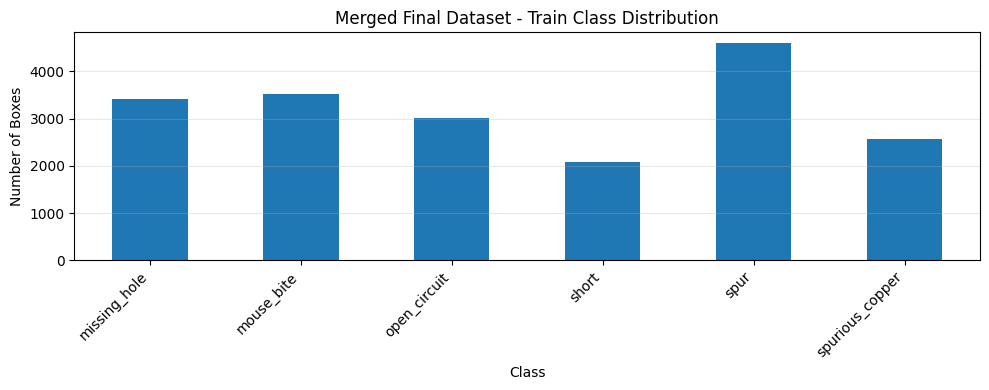

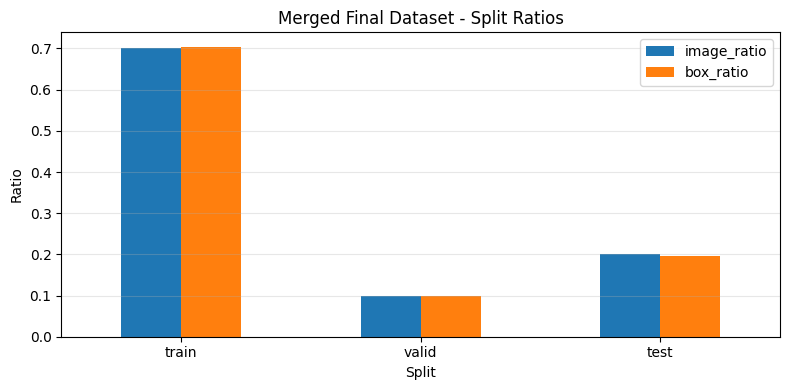

In [10]:
# Image and box split ratios
ratio_rows = []

image_counts = merged_summary_df.set_index("split")["num_images"].to_dict()
box_counts = merged_summary_df.set_index("split")["total_boxes"].to_dict()

total_images = sum(image_counts.values())
total_boxes = sum(box_counts.values())

for split in SPLITS:
    ratio_rows.append({
        "split": split,
        "num_images": int(image_counts.get(split, 0)),
        "image_ratio": image_counts.get(split, 0) / max(1, total_images),
        "num_boxes": int(box_counts.get(split, 0)),
        "box_ratio": box_counts.get(split, 0) / max(1, total_boxes),
    })

split_ratio_df = pd.DataFrame(ratio_rows)
display(split_ratio_df)

# Per-class distribution by split
class_pivot = merged_class_dist_df.pivot_table(
    index="class_name",
    columns="split",
    values="num_boxes",
    aggfunc="sum",
    fill_value=0,
).reindex(columns=SPLITS)

class_pivot["total"] = class_pivot[SPLITS].sum(axis=1)

for split in SPLITS:
    class_pivot[f"{split}_ratio"] = class_pivot[split] / class_pivot["total"].replace(0, pd.NA)

display(class_pivot)

split_ratio_df.to_csv(REPORT_DIR / "merged_split_ratio.csv", index=False)
class_pivot.to_csv(REPORT_DIR / "merged_per_class_split_ratio.csv")

# Train class distribution chart
train_dist = merged_class_dist_df[merged_class_dist_df["split"] == "train"].set_index("class_name")["num_boxes"]

ax = train_dist.plot(kind="bar", figsize=(10, 4))
ax.set_title("Merged Final Dataset - Train Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Boxes")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Split ratio chart
plot_df = split_ratio_df.set_index("split")[["image_ratio", "box_ratio"]]
ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_title("Merged Final Dataset - Split Ratios")
ax.set_xlabel("Split")
ax.set_ylabel("Ratio")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Source contribution analysis

In [11]:
# Because filenames are prefixed by source dataset name, source contribution can be recovered from file names.
source_rows = []

for split in SPLITS:
    img_dir = OUTPUT_DATASET_ROOT / split / "images"
    lbl_dir = OUTPUT_DATASET_ROOT / split / "labels"

    for img_path in list_images(img_dir):
        prefix = img_path.name.split("__", 1)[0] if "__" in img_path.name else "UNKNOWN"
        label_path = lbl_dir / f"{img_path.stem}.txt"
        objects, _ = read_yolo_label(label_path)

        c = class_counter_from_objects(objects)

        source_rows.append({
            "split": split,
            "source": prefix,
            "image": img_path.name,
            "num_boxes": len(objects),
            **{f"boxes_{STANDARD_NAMES[i]}": int(c.get(i, 0)) for i in range(len(STANDARD_NAMES))}
        })

source_contrib_df = pd.DataFrame(source_rows)

source_image_summary = source_contrib_df.groupby(["split", "source"]).agg(
    num_images=("image", "count"),
    num_boxes=("num_boxes", "sum"),
).reset_index()

display(source_image_summary)

source_class_rows = []
for _, row in source_contrib_df.iterrows():
    for cls_name in STANDARD_NAMES:
        source_class_rows.append({
            "split": row["split"],
            "source": row["source"],
            "class_name": cls_name,
            "num_boxes": int(row[f"boxes_{cls_name}"]),
        })

source_class_df = pd.DataFrame(source_class_rows)
source_class_summary = source_class_df.groupby(["split", "source", "class_name"])["num_boxes"].sum().reset_index()

display(source_class_summary)

source_contrib_df.to_csv(REPORT_DIR / "source_contribution_image_level.csv", index=False)
source_image_summary.to_csv(REPORT_DIR / "source_contribution_summary.csv", index=False)
source_class_summary.to_csv(REPORT_DIR / "source_contribution_class_summary.csv", index=False)

,split,source,num_images,num_boxes
0,test,DeepPCB,300,1844
1,test,DsPCBSD,1448,2927
2,test,HRIPCB,139,581
3,train,DeepPCB,1050,7166
4,train,DsPCBSD,5089,9936
5,train,HRIPCB,485,2074
6,valid,DeepPCB,150,1003
7,valid,DsPCBSD,718,1411
8,valid,HRIPCB,69,298


,split,source,class_name,num_boxes
0,test,DeepPCB,missing_hole,309
1,test,DeepPCB,mouse_bite,371
2,test,DeepPCB,open_circuit,338
3,test,DeepPCB,short,249
4,test,DeepPCB,spur,295
5,test,DeepPCB,spurious_copper,282
6,test,DsPCBSD,missing_hole,592
7,test,DsPCBSD,mouse_bite,542
8,test,DsPCBSD,open_circuit,350
9,test,DsPCBSD,short,176


## 12. Visual sanity check

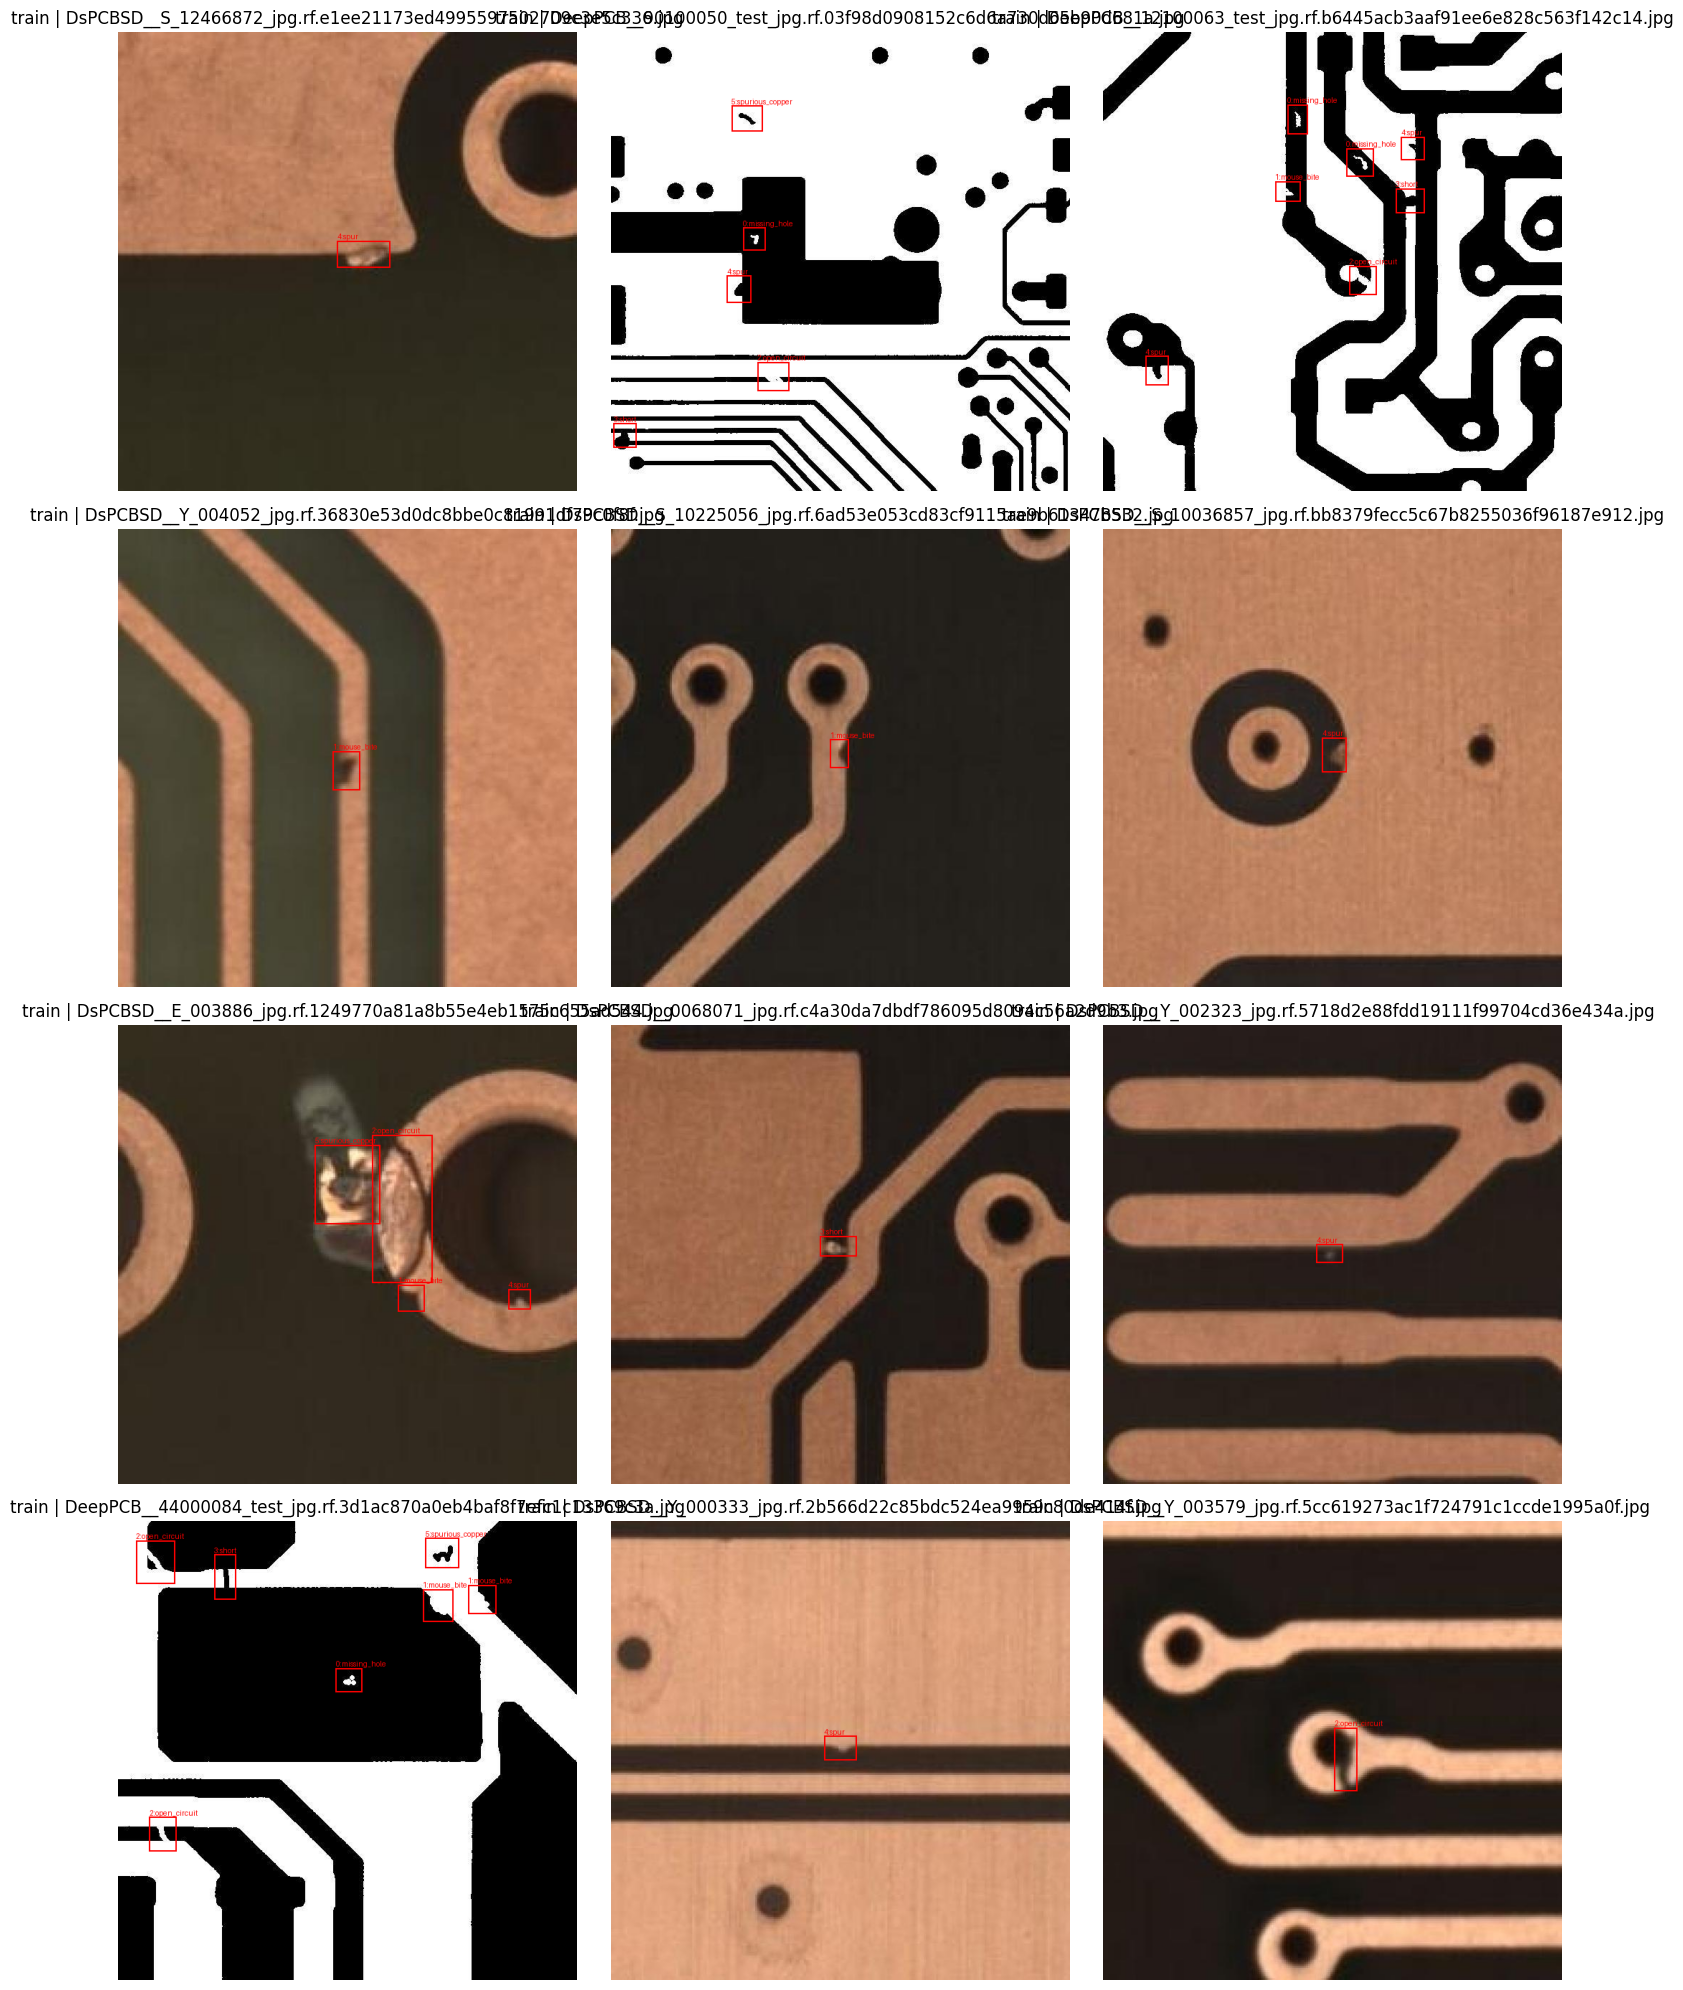

In [12]:
def yolo_to_xyxy(obj, W, H):
    x1 = (obj["x"] - obj["w"] / 2) * W
    y1 = (obj["y"] - obj["h"] / 2) * H
    x2 = (obj["x"] + obj["w"] / 2) * W
    y2 = (obj["y"] + obj["h"] / 2) * H
    return x1, y1, x2, y2

def visualize_image(dataset_root: Path, split: str, img_path: Path):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    draw = ImageDraw.Draw(img)

    lbl_dir = dataset_root / split / "labels"
    label_path = lbl_dir / f"{img_path.stem}.txt"
    objects, _ = read_yolo_label(label_path)

    for obj in objects:
        x1, y1, x2, y2 = yolo_to_xyxy(obj, W, H)
        cls_id = obj["cls_id"]
        cls_name = STANDARD_NAMES[cls_id] if 0 <= cls_id < len(STANDARD_NAMES) else str(cls_id)

        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1, max(0, y1 - 12)), f"{cls_id}:{cls_name}", fill="red")

    return img

def show_samples(dataset_root: Path, split="train", n=12, seed=42):
    import random
    random.seed(seed)

    img_dir = dataset_root / split / "images"
    images = list_images(img_dir)

    samples = random.sample(images, min(n, len(images)))

    cols = 3
    rows = (len(samples) + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, img_path in enumerate(samples, 1):
        vis = visualize_image(dataset_root, split, img_path)

        plt.subplot(rows, cols, i)
        plt.imshow(vis)
        plt.title(f"{split} | {img_path.name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(OUTPUT_DATASET_ROOT, split="train", n=12, seed=42)

## 13. Optional: create zip file for download

In [13]:
CREATE_ZIP = True

if CREATE_ZIP:
    if ZIP_PATH.exists():
        ZIP_PATH.unlink()

    # shutil.make_archive wants path without suffix.
    archive_base = ZIP_PATH.with_suffix("")
    shutil.make_archive(
        base_name=str(archive_base),
        format="zip",
        root_dir=str(WORK_ROOT),
        base_dir="DataPCB_Final_Clean_6cls",
    )

    print("Created:", ZIP_PATH)
    print("Size MB:", ZIP_PATH.stat().st_size / (1024 * 1024))
else:
    print("CREATE_ZIP=False")

Created: /kaggle/working/DataPCB_Final_Clean_6cls.zip
Size MB: 216.40005016326904


## 14. Final report paths

In [14]:
important_files = [
    "source_inspection.csv",
    "standardize_reports.json",
    "standardize_compact_report.csv",
    "standardized_source_summary.csv",
    "standardized_source_class_distribution.csv",
    "merged_dataset_summary.csv",
    "merged_class_distribution.csv",
    "merged_split_ratio.csv",
    "merged_per_class_split_ratio.csv",
    "source_contribution_summary.csv",
    "source_contribution_class_summary.csv",
    "merge_report.json",
    "merged_validation_issues.csv",
]

print("Final dataset:", OUTPUT_DATASET_ROOT)
print("data.yaml:", OUTPUT_DATASET_ROOT / "data.yaml")
print("reports:", REPORT_DIR)

print("\nImportant reports:")
for name in important_files:
    p = REPORT_DIR / name
    print("-", p, "| exists:", p.exists())

if ZIP_PATH.exists():
    print("\nZip:", ZIP_PATH)

Final dataset: /kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls
data.yaml: /kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls/data.yaml
reports: /kaggle/working/datapcb_final_clean_6cls/reports

Important reports:
- /kaggle/working/datapcb_final_clean_6cls/reports/source_inspection.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/standardize_reports.json | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/standardize_compact_report.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/standardized_source_summary.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/standardized_source_class_distribution.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/merged_dataset_summary.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/merged_class_distribution.csv | exists: True
- /kaggle/working/datapcb_final_clean_6cls/reports/merged_split_ratio.csv | exists

## What to use in training notebooks

Use this YAML path:

```python
DATA_YAML = "/kaggle/working/datapcb_final_clean_6cls/DataPCB_Final_Clean_6cls/data.yaml"
```

Important outputs to inspect:

```text
reports/merged_dataset_summary.csv
reports/merged_class_distribution.csv
reports/merged_split_ratio.csv
reports/merged_per_class_split_ratio.csv
reports/source_contribution_summary.csv
reports/source_contribution_class_summary.csv
```

Final policy summary:

```text
- DeepPCB: map to 6-class taxonomy.
- HRIPCB: map to 6-class taxonomy.
- DsPCBSD+: map HB/MB/OP/SH/SP/SC, remove CS/CFO/BMFO boxes.
- Drop image only if no valid 6-class box remains.
- Keep spur-only images.
- Preserve original train/valid/test split from each source dataset.
- Merge by split.
- No hard balancing.
```